In [1]:
import switchy.CloneStats as cs
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
import scanpy as sc
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import autoreload
import scipy
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 10,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 100
   }

mpl.rcParams.update(params)

sns.set_style("ticks")
sns.set_context(context='paper')
savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": False}
mpl.rc('savefig', dpi=300)
output_dir='../figures/ClonalGenesCorrelations/7.31.PaperDraft1'
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20) 
pd.set_option('display.width', 100)
%load_ext autoreload
%autoreload 2
cfgFile = '../switchy/Prototyping.ini'

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/numpy/lib/arraysetops.py:569: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


2861  Sites left after filtering to at least 1000 reads
2365  Sites left after filtering by number of independent cells expressing


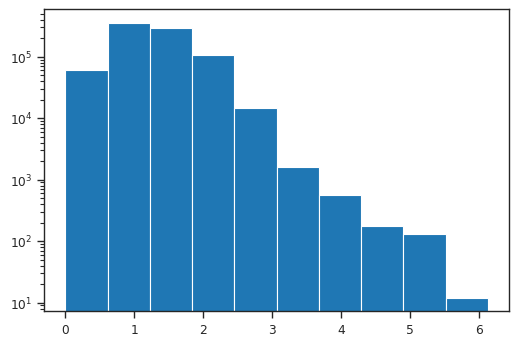

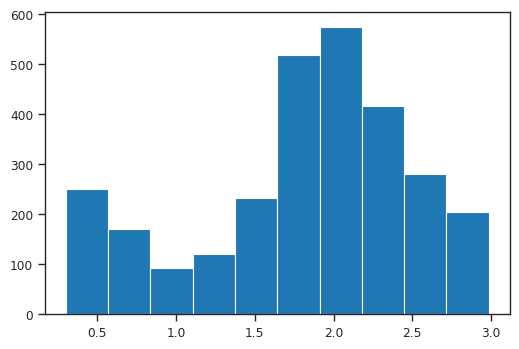

In [2]:
ase = pd.read_csv('../data/ASE/combinedASE.tab', sep = '\t', index_col=0)

ase['cell'] = ase.CELL.str.split('/', expand = True)[9]
ase.pop("CELL")

_s2 = ase['contig'].astype('str')


_s1 = ase['position'].astype(str)

ase['uniqueCoordinate'] = _s2 + "_" + _s1

## Feature Selection?

data = ase.groupby('uniqueCoordinate').sum()
fig, ax = plt.subplots(1,1)

plt.hist(np.log10(data.totalCount + 1))
plt.yscale('log')

# Select the Features where the unique Coordinate has more than 1000 counts
selector = data[data.totalCount > 1000].index


aseFiltered = ase[ase.uniqueCoordinate.isin(selector)]

# DataFrame to munge
_asemelt = aseFiltered[['cell', 'uniqueCoordinate', 'refCount', 'altCount']]

_asemelt = pd.melt(_asemelt, id_vars = ['cell', 'uniqueCoordinate'], value_vars=['refCount', 'altCount'])

# number of independent cells in which a variant is called
fig, ax = plt.subplots(1,1)
x = _asemelt.uniqueCoordinate.value_counts().values
plt.hist(np.log10(x))
plt.yscale('linear')


# filter for variants which appear in more than 10 cells (this necessarily excludes some private clonal variation which one could look into)
print(_asemelt.uniqueCoordinate.nunique(), " Sites left after filtering to at least 1000 reads")
_selectionframe = _asemelt.uniqueCoordinate.value_counts().to_frame()
selector = _selectionframe.index[_selectionframe.uniqueCoordinate > 10]

_asemelt = _asemelt[_asemelt.uniqueCoordinate.isin(selector)]
print(_asemelt.uniqueCoordinate.nunique(), " Sites left after filtering by number of independent cells expressing")

_df = _asemelt
_asemelt['uniqueFeature'] = _asemelt['uniqueCoordinate'] + '_' + _asemelt['variable']

_asemelt = _asemelt[['uniqueFeature', 'cell', 'value']]

_asesinglecells = _asemelt.pivot(index = 'cell', columns='uniqueFeature', values = 'value')

_asesinglecells.fillna(0, inplace = True)

_aselog = np.log10(_asesinglecells + 1)



In [3]:
_df

,cell,uniqueCoordinate,variable,value,uniqueFeature
0,D2_5_10_SplitSort_Dilution_Combined_L20,1_631193,refCount,3,1_631193_refCount
1,D2_5_10_SplitSort_Dilution_Combined_L20,1_28236165,refCount,7,1_28236165_refCount
2,D2_5_10_SplitSort_Dilution_Combined_L20,1_30732949,refCount,8,1_30732949_refCount
3,D2_5_10_SplitSort_Dilution_Combined_L20,1_92832041,refCount,6,1_92832041_refCount
4,D2_5_10_SplitSort_Dilution_Combined_L20,1_93879160,refCount,3,1_93879160_refCount
...,...,...,...,...,...
442867,D2_5_10_SplitSort_Dilution_Combined_M10,KI270733.1_135086,altCount,30,KI270733.1_135086_altCount
442868,D2_5_10_SplitSort_Dilution_Combined_M10,KI270733.1_135090,altCount,30,KI270733.1_135090_altCount
442869,D2_5_10_SplitSort_Dilution_Combined_M10,KI270733.1_135097,altCount,29,KI270733.1_135097_altCount
442870,D2_5_10_SplitSort_Dilution_Combined_M10,KI270733.1_135110,altCount,30,KI270733.1_135110_altCount


/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/seaborn/matrix.py:649: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


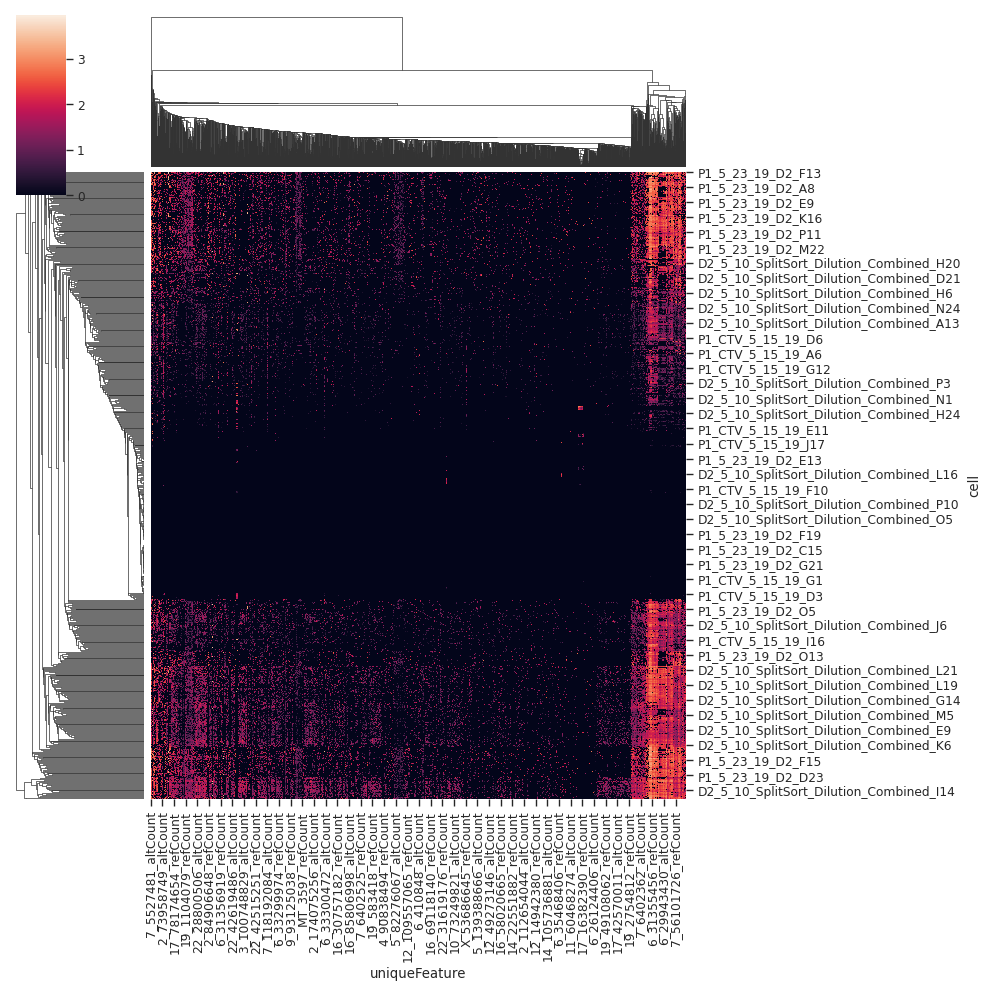

In [4]:
sns.clustermap(_aselog)

In [25]:
parameters, io, config = cs.readConfig(cfgFile)
    
adata, df = cs.prepareData(io['CountsFile'],
                                parameters['datatype'], 
                                parameters.getboolean('highly_variable'),
                                int(parameters['n_highly_variable']),
                                parameters.getboolean('onlyClones'), 
                                parameters.getboolean('remove_immune_receptors'), 
                                parameters.getboolean('normalize'),
                                parameters.getboolean('filterCells'))

(1350, 10) (14714, 2) shape of adata after filtering 


In [26]:
adata.obs.CLONE

cell
CTY_I8                                     1160.0
MS_SISTER2_J10                              427.0
NaiveBcellsplate2_20180629_D23              248.0
NaiveBcellsplate2_20180629_K4                40.0
NaiveBcellsplate2_20180629_P1               565.0
                                            ...  
P1_5_23_19_D2_H8                           1687.0
P1_5_23_19_D2_A19                          1149.0
P1_5_23_19_D2_M5                           1618.0
P1_CTV_5_15_19_M19                         1538.0
D2_5_10_SplitSort_Dilution_Combined_M10    1391.0
Name: CLONE, Length: 1350, dtype: float64

In [27]:
adata.obs

,Donor,Experimental_Label,Treatment,Division_Number,CLONE,ISOTYPE,SEQUENCE_ID,Assembly,n_genes,n_counts
cell,,,,,,,,,,
CTY_I8,Donor_1,Activation_1,Activation,4,1160.0,IGHM,bracer_CTY_I8_TRINITY_DN0_c0_g1_i1_H Donor_1,AAGGTGTCCAGTGTGAAGTGCAGCTGGTGGAGTCTGGGGGAGGCTT...,7439,1453394.0
MS_SISTER2_J10,Donor_1,Activation_2,Activation,3,427.0,IGHD,bracer_MS_SISTER2_J10_TRINITY_DN2_c0_g3_i1_H D...,ATGGGTCCTGTCCCAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTG...,9518,977415.0
NaiveBcellsplate2_20180629_D23,Donor_1,Naive_1,Naive,None,248.0,IGHM,bracer_NaiveBcellsplate2_20180629_D23_TRINITY_...,GTCGTCAGATCTCAGGCTCCTCACCATGGACTGGACCTGGAGCATC...,2119,1155249.0
NaiveBcellsplate2_20180629_K4,Donor_1,Naive_1,Naive,None,40.0,nan,nan,nan,1267,391289.0
NaiveBcellsplate2_20180629_P1,Donor_1,Naive_1,Naive,None,565.0,IGHD,bracer_NaiveBcellsplate2_20180629_P1_TRINITY_D...,GTACATGGGGCTTTCTGAGAGTCATGGATCTCATGTGCAAGAAAAT...,2329,1139509.0
...,...,...,...,...,...,...,...,...,...,...
P1_5_23_19_D2_H8,Donor_2,Activation_4,Activation,Max,1687.0,nan,nan,nan,3845,410208.0
P1_5_23_19_D2_A19,Donor_2,Activation_4,Activation,Max,1149.0,IGHM,bracer_P1_5_23_19_D2_A19_TRINITY_DN4_c0_g1_i4_...,TCTGAGGATCTCCTGTAAGGGTTCTGGATACAGCTTTACCAGCTAC...,4573,2044758.0
P1_5_23_19_D2_M5,Donor_2,Activation_4,Activation,Max,1618.0,IGHG2,bracer_P1_5_23_19_D2_M5_TRINITY_DN3_c1_g1_i1_H...,TGGTGGCAGCAGCTACAGGTGTCCAGTCCCAGGTGCAGCTGGTGCA...,3340,1034566.0


so the question is, for each feature are clones concordant in their choice of allele? 

pseudocode: 

for each comparison: 
    do the statistical comparison which measures concordance
    We want to take the set of unique Coordinates that are present in both cells
    Could include a test for 'allelic mapping bias', probably would do this on the full data frame
    if cell1[uniqueCoordinate][refCount] > cell1[uniqueCoordinate][altCount]
        append a 1 to the cell1 'allele choice vector'
    if cell2 yada yada
        append a 1 to the cell2 'allele choice vector'

In [7]:
_df = _df[_df.value > 3]

In [8]:
_df.groupby(['uniqueCoordinate', 'variable']).sum()

value
uniqueCoordinate variable       
10_1000772       altCount   3733
                 refCount   3856
10_100347494     altCount   2900
                 refCount   2769
10_100356554     altCount   3278
...                          ...
X_74226777       refCount   5566
X_74226778       altCount   1121
                 refCount   1704
Y_2865219        altCount    274
                 refCount    746

[4730 rows x 1 columns]

In [9]:
groupedbyCoordSum = _df.groupby(['uniqueCoordinate', 'variable']).sum()

In [10]:
refcounts = groupedbyCoordSum.xs(axis = 0, key = 'refCount', level = 1)['value']

In [11]:
refcounts

uniqueCoordinate
10_1000772      3856
10_100347494    2769
10_100356554    3386
10_100360769     642
10_102425196     911
                ... 
X_74226752       995
X_74226767      4613
X_74226777      5566
X_74226778      1704
Y_2865219        746
Name: value, Length: 2365, dtype: int64

In [12]:
altcounts = groupedbyCoordSum.xs(axis = 0, key = 'altCount', level = 1)['value']

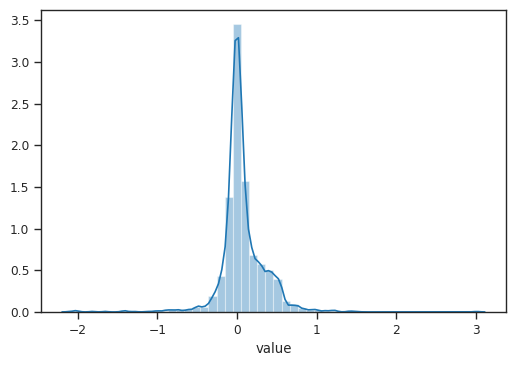

In [13]:

sns.distplot(np.log10(refcounts) - np.log10(altcounts))

In [14]:
bias = refcounts / altcounts

Text(0, 0.5, 'Alternate Counts')

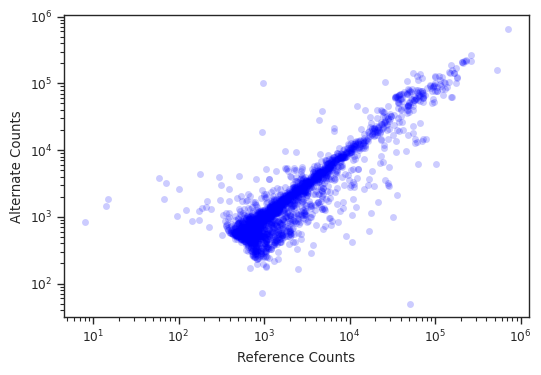

In [15]:
fig, ax = plt.subplots(1,1)

x = refcounts
y = altcounts

plt.scatter(x = x, y = y, c = 'b', alpha = 0.2, linewidths=0.1)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Reference Counts')
plt.ylabel('Alternate Counts')

In [21]:
# Are Clones more Allelically Concordant than non-clones?
def createClonalComparisondf(df, adata):
    comparison = []
    clonal = []
    division_sum = []
    division_diff = []
    for cell1, cell2 in itertools.combinations(df.index, 2):
        # Clone Test Comparison
        if adata.obs.loc[cell1].CLONE == adata.obs.loc[cell2].CLONE:
            clonal.append(1)
        else:
            clonal.append(0)
        # Add Comparison Name    
        comparison.append(cell1 + '*' + cell2)
        # Add Division Numbers
        division_sum.append(adata.obs.loc[cell1].Division_Number + adata.obs.loc[cell2].Division_Number)
        division_diff.append(adata.obs.loc[cell1].Division_Number - adata.obs.loc[cell2].Division_Number)
    # Construct the df
    divisiondf = pd.DataFrame([comparison, clonal, division_sum, division_diff])
    divisiondf = divisiondf.T
    # Possibly not necessary at this point but don't want to mess up the merge wihtout testing
    cells = divisiondf.iloc[:,0].str.split('*', expand = True)
    divisiondf = pd.merge(cells, divisiondf, left_index=True, right_index=True)
    divisiondf.columns = ['cell1', 'cell2', 'Comparison', 'ClonalBool', 'DivisionSum', 'DivisionDiff']
    return divisiondf

In [22]:
# Replace None with No Tracking
adata.obs.loc[:,'Division_Number'] = adata.obs.Division_Number.str.replace('None', 'No Tracking')
# Replace No Tracking with 100 for easy numeric filtering
adata.obs.loc[:,'Division_Number'] = adata.obs.Division_Number.str.replace('No Tracking', '100')
# Replace max with 7, which really should be 7+
adata.obs.loc[:,'Division_Number'] = adata.obs.Division_Number.str.replace('Max', '7')
# make string numeric for filtering purposes
adata.obs['Division_Number'] = pd.to_numeric(adata.obs['Division_Number'])

In [23]:
import itertools
divisiondf = createClonalComparisondf(df, adata)

In [24]:
divisiondf

,cell1,cell2,Comparison,ClonalBool,DivisionSum,DivisionDiff
0,CTY_I8,MS_SISTER2_J10,CTY_I8*MS_SISTER2_J10,0,7,1
1,CTY_I8,NaiveBcellsplate2_20180629_D23,CTY_I8*NaiveBcellsplate2_20180629_D23,0,104,-96
2,CTY_I8,NaiveBcellsplate2_20180629_K4,CTY_I8*NaiveBcellsplate2_20180629_K4,0,104,-96
3,CTY_I8,NaiveBcellsplate2_20180629_P1,CTY_I8*NaiveBcellsplate2_20180629_P1,0,104,-96
4,CTY_I8,CTY_L1,CTY_I8*CTY_L1,0,11,-3
...,...,...,...,...,...,...
910570,P1_5_23_19_D2_A19,P1_CTV_5_15_19_M19,P1_5_23_19_D2_A19*P1_CTV_5_15_19_M19,0,14,0
910571,P1_5_23_19_D2_A19,D2_5_10_SplitSort_Dilution_Combined_M10,P1_5_23_19_D2_A19*D2_5_10_SplitSort_Dilution_C...,0,14,0
910572,P1_5_23_19_D2_M5,P1_CTV_5_15_19_M19,P1_5_23_19_D2_M5*P1_CTV_5_15_19_M19,0,14,0
910573,P1_5_23_19_D2_M5,D2_5_10_SplitSort_Dilution_Combined_M10,P1_5_23_19_D2_M5*D2_5_10_SplitSort_Dilution_Co...,0,14,0
